# Analysis of 2D noise properties. If you already have generated the noise*nc file you can use
# the more simple notebook: noise_analysis_2D_only_20km_L2_med_from_segments.ipynb
# This notebook actually generates that file from various data sources (spectra of SSH and model output)

In [1]:
import netCDF4 as nc
import glob
import xarray as xr
import pandas as pd
import xrft
from scipy.io import loadmat
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import least_squares
from scipy.optimize import curve_fit
from scipy.special import gamma, kv
from numpy.linalg import inv
import mpmath as mp
import math
from math import sin, cos, sqrt, atan2, radians
import datetime
from matplotlib import pyplot as plt, animation
from mpl_toolkits.axes_grid1 import make_axes_locatable
import scipy.signal as signal
import numpy as np
from scipy.ndimage import gaussian_filter
import scipy.io as sio
from scipy.stats import chi2
import scipy.stats as stats

from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.gridspec as gridspec
import sys as sys
import os
import matplotlib as mpl
from scipy.stats import pearsonr
from scipy.stats import linregress

sys.path.append('../src/')
import swot_swell_utils as swell
from  lib_filters_obp import *
from ipywidgets import interact, IntSlider, FloatRangeSlider,  FloatSlider, ToggleButtons
from ipywidgets import interactive_output, GridBox, Layout
from IPython.display import display
import matplotlib.colors as mcolors


from spectral_analysis_functions import detrend_2d_quadratic,detrend_2d_bilinear

In [2]:
pass_number = 3
min_cycle = 473
max_cycle = 578
lat_min = 40.4 #-56.5
lat_max = 42.8 #-53.5

spass= f"{pass_number:03d}"
ana_tag='L2_D_20km_calval_pass03_med'
dirroot='/media/ardhuin/FabLinux/'
path1=dirroot+'SWOT2/Basic_D/*/'
path2=dirroot+'SWOT2/WindWave/'

model_dir = dirroot+"/WW3-CCI/"
model_files = sorted(glob.glob(os.path.join(model_dir, "CCI_WW3-GLOB-30M_2023??_hs.nc")))
print(model_files)



num_cycles = max_cycle - min_cycle + 1

['/media/ardhuin/FabLinux//WW3-CCI/CCI_WW3-GLOB-30M_202301_hs.nc', '/media/ardhuin/FabLinux//WW3-CCI/CCI_WW3-GLOB-30M_202302_hs.nc', '/media/ardhuin/FabLinux//WW3-CCI/CCI_WW3-GLOB-30M_202303_hs.nc', '/media/ardhuin/FabLinux//WW3-CCI/CCI_WW3-GLOB-30M_202304_hs.nc', '/media/ardhuin/FabLinux//WW3-CCI/CCI_WW3-GLOB-30M_202305_hs.nc', '/media/ardhuin/FabLinux//WW3-CCI/CCI_WW3-GLOB-30M_202306_hs.nc', '/media/ardhuin/FabLinux//WW3-CCI/CCI_WW3-GLOB-30M_202307_hs.nc', '/media/ardhuin/FabLinux//WW3-CCI/CCI_WW3-GLOB-30M_202308_hs.nc', '/media/ardhuin/FabLinux//WW3-CCI/CCI_WW3-GLOB-30M_202309_hs.nc', '/media/ardhuin/FabLinux//WW3-CCI/CCI_WW3-GLOB-30M_202310_hs.nc', '/media/ardhuin/FabLinux//WW3-CCI/CCI_WW3-GLOB-30M_202311_hs.nc', '/media/ardhuin/FabLinux//WW3-CCI/CCI_WW3-GLOB-30M_202312_hs.nc']


In [3]:
# find the first cycle which contains the selected path
found_nothing = True
cycle = min_cycle - 1

while (found_nothing == True):
    cycle +=1
    path = glob.glob(path1+'SWOT_L2_LR_SSH_Basic_'+str(cycle).zfill(3)+'_'+str(pass_number).zfill(3)+'_*.nc')
    print('cycle:',cycle,path)
    # path = glob.glob('../SWOT_L2_LR_SSH_1.1/SWOT_L2_LR_SSH_Basic_'+str(cycle).zfill(3)+'_'+str(pass_number).zfill(3)+'_*.nc')
    if path == []:
        continue
    else:
        found_nothing = False

if (found_nothing == False):
    print(path)

cycle: 473 ['/media/ardhuin/FabLinux/SWOT2/Basic_D/cycle_473/SWOT_L2_LR_SSH_Basic_473_003_20230327T235338_20230328T004445_PGD0_01.nc']
['/media/ardhuin/FabLinux/SWOT2/Basic_D/cycle_473/SWOT_L2_LR_SSH_Basic_473_003_20230327T235338_20230328T004445_PGD0_01.nc']


In [4]:
first_pass_data = nc.Dataset(path[0], 'r')
fp_latitude = first_pass_data['latitude']
fp_shape = np.shape(fp_latitude)
# left_edge = fp_shape[1] - 6
#we are ignoring the five outer grid points, but subtract 6 because of Python's zero indexing
lat_edge = fp_latitude[:,35]

#find min and max line indices
indx = np.nonzero((lat_edge >= lat_min) & (lat_edge <= lat_max))[0]
track_length = np.shape(indx)[0]
print(track_length)

137


In [5]:
#find cycles with given pass
cycle_list = np.empty(0)
num_useful_cycles = 0
for cycle in range(min_cycle,max_cycle+1):
    # path = glob.glob('../SWOT_L2_LR_SSH_1.1/SWOT_L2_LR_SSH_Basic_'+str(cycle).zfill(3)+'_'+str(pass_number).zfill(3)+'_*.nc')
    path = glob.glob(path1+'SWOT_L2_LR_SSH_Basic_'+str(cycle).zfill(3)+'_'+str(pass_number).zfill(3)+'_*.nc')
    if path == []:
        continue
    else:
        cycle_list = np.append(cycle_list,cycle)
        num_useful_cycles += 1

print(num_useful_cycles)

101


In [6]:
lat_array = np.empty((num_useful_cycles,2,track_length,25))
lat_array[:] = np.nan
lon_array = np.empty((num_useful_cycles,2,track_length,25))
lon_array[:] = np.nan
ssha_array = np.empty((num_useful_cycles,2,track_length,25))
ssha_array[:] = np.nan
n_cross = 20     #  cross-track pixels used for 2D FFT 
uncert_array = np.empty((num_useful_cycles,2,track_length,n_cross))
uncert_array[:] = np.nan
sig0_array = np.empty((num_useful_cycles,2,track_length,25))
sig0_array[:] = np.nan
tides = np.empty((num_useful_cycles,2,track_length,25))
tides[:] = np.nan
time_array = np.empty((num_useful_cycles,2,track_length))
time_array[:] = np.nan
num_useful_strips = 0
num_bad_strips = 0

good_strips_list = np.array([[0,0]])
flag_strips_list=np.array([[0,0]])
for n,cycle in enumerate(cycle_list):
    path = glob.glob(path1+'SWOT_L2_LR_SSH_Basic_'+str(int(cycle)).zfill(3)+'_'+str(pass_number).zfill(3)+'_*.nc')
    if path == []:
        continue
    data = nc.Dataset(path[0],'r')
    ssha_strip = data['ssha_karin_2'][indx,:]
    uncert= data['ssh_karin_uncert'][indx,:]
    # ssha_strip = data['ssha_karin'][indx,:]
    ssha_qual = data['ssha_karin_2_qual'][indx,:]
    xover_cor = data['height_cor_xover'][indx,:]# Additional correction provided by SWOT
    xover_cor_qual = data['height_cor_xover_qual'][indx,:]# Additional quality flag
    internal_tide_hret = data['internal_tide_hret'][indx,:] #internal tide correction I will add back  
    lat_strip = data['latitude'][indx,:]
    lon_strip = data['longitude'][indx,:]
    time_strip = data['time'][indx]
    for side in range(2):
        start_index = 5 + 34*side
        if np.ma.is_masked(ssha_strip[:,start_index:(start_index + 25)]) == True:
            num_bad_strips +=1
            continue
        if np.ma.is_masked(xover_cor[:,start_index:(start_index + 25)]) == True:
            num_bad_strips +=1
            continue
        flagstrip=0
        if np.any(ssha_qual[:,start_index:(start_index + 25)]) == True: 
            flagstrip=1
            flag_strips_list = np.concatenate((flag_strips_list,[[n,side]]))
            num_bad_strips +=1
            continue
        num_useful_strips +=1
        lat_array[n,side,:,:] = lat_strip[:,start_index:(start_index + 25)]
        lon_array[n,side,:,:] = lon_strip[:,start_index:(start_index + 25)]
        ssha_array[n,side,:,:] = ssha_strip[:,start_index:(start_index + 25)] + xover_cor[:,start_index:(start_index + 25)] - internal_tide_hret[:,start_index:(start_index + 25)]
        if side==1:
            start_u=3+start_index
        else:
            start_u=2+start_index
        uncert_array[n,side,:,:] = uncert[:,start_u:start_u+n_cross]
        tides[n,side,:,:] = internal_tide_hret[:,start_index:(start_index + 25)]
        time_array[n,side,:] = time_strip
        good_strips_list = np.concatenate((good_strips_list,[[n,side]]))
    data.close()
good_strips_list = np.delete(good_strips_list,0,0)
flag_strips_list = np.delete(flag_strips_list,0,0)

In [7]:
print(num_useful_strips)
seg_length = 20  # along-track pixels (~40 km)
n_cross = 20     # total cross-track pixels
num_seg = track_length // seg_length
num_useful_strips = len(good_strips_list)

151


In [8]:
# ----------------------------
# 1. Compute segment-mean lat/lon/time
# ----------------------------

# Preallocate arrays
lat_seg_mean = np.full((num_useful_strips, num_seg), np.nan)
lon_seg_mean = np.full((num_useful_strips, num_seg), np.nan)
tswot_seg_mean = np.full((num_useful_strips, num_seg), np.nan)
uncert_seg_var = np.full((num_useful_strips, num_seg), np.nan)

print('size:',np.shape(uncert_array),np.shape(lat_array),np.shape(lat_strip))

for i, (cycle_idx, side_idx) in enumerate(good_strips_list):
    lat_strip = lat_array[cycle_idx, side_idx, :, :]
    lon_strip = lon_array[cycle_idx, side_idx, :, :]
    time_strip = time_array[cycle_idx, side_idx, :]
    uncert_strip=uncert_array[cycle_idx, side_idx, :,:]
    n_along = lat_strip.shape[0]
    seg_edges = np.linspace(0, n_along, num_seg + 1, dtype=int)
    
    for s in range(num_seg):
        idx_start = seg_edges[s]
        idx_end = seg_edges[s + 1]
        
        # Cross-track mean
        lat_seg_mean[i, s] = np.nanmean(lat_strip[idx_start:idx_end, :])
        lon_seg_mean[i, s] = np.nanmean(lon_strip[idx_start:idx_end, :])
        tswot_seg_mean[i, s] = np.nanmean(time_strip[idx_start:idx_end])
        uncert_seg_var[i, s] = np.nanmean((uncert_strip[idx_start:idx_end,:].flatten())**2)


# Flatten to 1D arrays for DataFrame and interpolation
lat_seg_mean_flat = lat_seg_mean.flatten()
lon_seg_mean_flat = lon_seg_mean.flatten()
tswot_seg_mean_flat = tswot_seg_mean.flatten()

num_segments_total = lat_seg_mean_flat.size

# Convert to datetime
epoch_time = datetime.datetime(1970, 1, 1)
dt_ref = datetime.datetime(2000, 1, 1)
delta = (dt_ref - epoch_time).total_seconds()

tswot_seg_datetime = np.array([
    epoch_time + datetime.timedelta(seconds=(t + delta))
    for t in tswot_seg_mean_flat
])

# Fix longitudes if necessary
lon_seg_mean_flat = np.where(lon_seg_mean_flat > 180, lon_seg_mean_flat - 360, lon_seg_mean_flat)

# ----------------------------
# 2. Interpolate WW3 model variables
# ----------------------------

hs_model_seg = np.full(num_segments_total, np.nan)
qkk_model_seg = np.full(num_segments_total, np.nan)
wnd_model_seg = np.full(num_segments_total, np.nan)
fp_model_seg = np.full(num_segments_total, np.nan)

for model_file in model_files:
    print(f"Processing {model_file}")
    ds = xr.open_dataset(model_file)
    
    tmin = pd.to_datetime(ds.time.values[0])
    tmax = pd.to_datetime(ds.time.values[-1])
    
    tswot_seg_pd = pd.to_datetime(tswot_seg_datetime)
    idx = np.where((tswot_seg_pd >= tmin) & (tswot_seg_pd <= tmax))[0]
    
    if len(idx) == 0:
        ds.close()
        continue
    
    hs_sub = ds['hs'].interp(longitude=('points', lon_seg_mean_flat[idx]),
                             latitude=('points', lat_seg_mean_flat[idx]),
                             time=('points', tswot_seg_pd[idx]))
    
    fp_sub = ds['fp'].interp(longitude=('points', lon_seg_mean_flat[idx]),
                             latitude=('points', lat_seg_mean_flat[idx]),
                             time=('points', tswot_seg_pd[idx]))
    
    qkk_sub = ds['qkk'].interp(longitude=('points', lon_seg_mean_flat[idx]),
                               latitude=('points', lat_seg_mean_flat[idx]),
                               time=('points', tswot_seg_pd[idx]))
    wndu = ds['uwnd'].interp(longitude=('points', lon_seg_mean_flat[idx]),
                               latitude=('points', lat_seg_mean_flat[idx]),
                               time=('points', tswot_seg_pd[idx]))
    wndv = ds['vwnd'].interp(longitude=('points', lon_seg_mean_flat[idx]),
                               latitude=('points', lat_seg_mean_flat[idx]),
                               time=('points', tswot_seg_pd[idx]))
    
    hs_model_seg[idx] = hs_sub.values
    fp_model_seg[idx] = fp_sub.values
    qkk_model_seg[idx] = qkk_sub.values
    wnd_model_seg[idx] = np.sqrt(wndu.values**2+wndv.values**2)
    
    ds.close()

size: (101, 2, 137, 20) (101, 2, 137, 25) (137, 69)
Processing /media/ardhuin/FabLinux//WW3-CCI/CCI_WW3-GLOB-30M_202301_hs.nc
Processing /media/ardhuin/FabLinux//WW3-CCI/CCI_WW3-GLOB-30M_202302_hs.nc
Processing /media/ardhuin/FabLinux//WW3-CCI/CCI_WW3-GLOB-30M_202303_hs.nc
Processing /media/ardhuin/FabLinux//WW3-CCI/CCI_WW3-GLOB-30M_202304_hs.nc
Processing /media/ardhuin/FabLinux//WW3-CCI/CCI_WW3-GLOB-30M_202305_hs.nc
Processing /media/ardhuin/FabLinux//WW3-CCI/CCI_WW3-GLOB-30M_202306_hs.nc
Processing /media/ardhuin/FabLinux//WW3-CCI/CCI_WW3-GLOB-30M_202307_hs.nc
Processing /media/ardhuin/FabLinux//WW3-CCI/CCI_WW3-GLOB-30M_202308_hs.nc
Processing /media/ardhuin/FabLinux//WW3-CCI/CCI_WW3-GLOB-30M_202309_hs.nc
Processing /media/ardhuin/FabLinux//WW3-CCI/CCI_WW3-GLOB-30M_202310_hs.nc
Processing /media/ardhuin/FabLinux//WW3-CCI/CCI_WW3-GLOB-30M_202311_hs.nc
Processing /media/ardhuin/FabLinux//WW3-CCI/CCI_WW3-GLOB-30M_202312_hs.nc


In [9]:
print(np.shape(tswot_seg_datetime),num_useful_strips, num_seg)

(906,) 151 6


In [10]:
# --- Initialize arrays ---
noise_250k = np.full((num_useful_strips, num_seg), np.nan)
noise_250l = np.full((num_useful_strips, num_seg), np.nan)
noise_250m = np.full((num_useful_strips, num_seg), np.nan)
noise_250n = np.full((num_useful_strips, num_seg), np.nan)

noise_250k_f = np.full((num_useful_strips, num_seg), np.nan)
noise_250l_f = np.full((num_useful_strips, num_seg), np.nan)

noise_250k_n = np.full((num_useful_strips, num_seg), np.nan)
noise_250l_n = np.full((num_useful_strips, num_seg), np.nan)

hs_model_2D = np.full((num_useful_strips, num_seg), np.nan)
qkk_model_2D = np.full((num_useful_strips, num_seg), np.nan)
wnd_model_2D = np.full((num_useful_strips, num_seg), np.nan)


# Arrays to store the indices of the minimum value for each segment
min_indices_fy = np.full((num_useful_strips, num_seg), np.nan, dtype=int)
min_indices_fx = np.full((num_useful_strips, num_seg), np.nan, dtype=int)
max_indices_fy = np.full((num_useful_strips, num_seg), np.nan, dtype=int)
max_indices_fx = np.full((num_useful_strips, num_seg), np.nan, dtype=int)

# --- Storage for SSH filename and indices ---
ssh_filenames = np.empty((num_useful_strips), dtype=object)

i1_indices = np.full((num_useful_strips, num_seg), np.nan)
i2_indices = np.full((num_useful_strips, num_seg), np.nan)
j1_indices = np.full((num_useful_strips, num_seg), np.nan)
j2_indices = np.full((num_useful_strips, num_seg), np.nan)
track_angle = np.full((num_useful_strips, num_seg), np.nan)
uncertainty = np.full((num_useful_strips, num_seg), np.nan)
uncertainty_std = np.full((num_useful_strips, num_seg), np.nan)
uncertainty_near= np.full((num_useful_strips, num_seg), np.nan)
uncertainty_farr= np.full((num_useful_strips, num_seg), np.nan)
sigma0_std= np.full((num_useful_strips, num_seg), np.nan)


# --- Initialize the Dataset ---
# We'll fill Efxfy as we go
nfy=21;nfx=20
Efxfy_data = np.full((num_useful_strips, num_seg, nfy, nfx), np.nan)
Efxfy_unce = np.full((num_useful_strips, num_seg, nfy, nfx), np.nan)
Efxfy_near = np.full((num_useful_strips, num_seg, nfy, nfx), np.nan)
Efxfy_farr = np.full((num_useful_strips, num_seg, nfy, nfx), np.nan)
time_arr = np.empty((num_useful_strips, num_seg), dtype="datetime64[ns]")
side_arr=np.full((num_useful_strips), np.nan)
 

print('tswot_seg_mean type:',type(tswot_seg_mean))
print(tswot_seg_mean.dtype)
print(tswot_seg_mean[:5])

ds_seg = xr.Dataset(
    coords={
        "strip_id": np.arange(num_useful_strips),
        "segment_id": np.arange(num_seg),
        "fy": np.arange(nfy),
        "fx": np.arange(nfx),
    }
)

first=0

# --- Main loop ---
for i, (cycle_idx, side_idx) in enumerate(good_strips_list):
  if good_strips_list[i,1]==0 :
    side_arr[i]=0
  else: 
    side_arr[i]=1
      
  cycle = f'{int(cycle_list[cycle_idx]):03d}'
  filename = dirroot + 'SWOT2/L2_D_WindWave_res3u/SWOT_L2_LR_WIND_WAVE_' + cycle + '_'+spass+'_202*_v2.1_beta.nc'
  file_listnc = sorted(glob.glob(filename))
  if (len(file_listnc) >0):
    #print('file test:', file_listnc[0])
    L3Snc = xr.open_dataset(file_listnc[0])
    filetest=file_listnc[0].replace("L2_D_WindWave_res3u", "Unsmoothed").replace("WIND_WAVE", "SSH_Unsmoothed").replace("v2.1_beta", "PGD0_01").replace("FabLinux","FabBack")
    print('filename:',filename)
    ssh_filenames[i]=ssh_file = (lambda f: f if os.path.exists(f) else None)(filetest)
    print('ssh filename:',ssh_filenames[i])
      
    #ssh_filenames[i]=ssh_file = (lambda f: f if os.path.exists(f) else None)(file_listnc[0].replace("L2_WindWave_res3", "Unsmoothed").replace("WIND_WAVE", "SSH_Unsmoothed").replace("v2.1_beta", "v2.0.1"))
    
    print('file:', filename, i, cycle_idx, side_idx)
    #print('filetest:', filetest,'##', ssh_filenames[i])
    lat_spec = L3Snc.latitude.values
    lon_spec = L3Snc.longitude.values
    urms  = L3Snc.ssh_uncertainty.values
    ustd  = L3Snc.ssh_uncertainty_std.values
    lon_spec = np.where(lon_spec > 180, lon_spec - 360, lon_spec)

    n_along = lat_strip.shape[0]
    seg_edges = np.linspace(0, n_along, num_seg + 1, dtype=int)

    for s in range(num_seg):
        index_1d = i *num_seg + s
        hs_model_2D[i,s]=hs_model_seg[index_1d]
        qkk_model_2D[i,s]=qkk_model_seg[index_1d]
        wnd_model_2D[i,s]=wnd_model_seg[index_1d]
        

        time_arr[i,s] = np.datetime64(tswot_seg_datetime[index_1d])
        lat0 = lat_seg_mean[i, s]
        clat = np.cos(lat0 * np.pi / 180)
        lon0 = lon_seg_mean[i, s]
        if lon0 > 180:
            lon0 -= 360
        if (s==0 & i==0): 
            filter_PTR=L3Snc.filter_PTR.copy()
            filter_OBP=L3Snc.filter_OBP.copy()
        dist2 = (lat_spec - lat0)**2 + (lon_spec - lon0)**2 * clat**2
        ibox = np.nanargmin(dist2)
        uncertainty[i,s] = np.sqrt((L3Snc.ssh_uncertainty[ibox]**2+L3Snc.ssh_uncertainty[ibox+6]**2+L3Snc.ssh_uncertainty[ibox-6]**2)/3)
        uncertainty_std[i,s] = np.sqrt((L3Snc.ssh_uncertainty_std[ibox]**2+L3Snc.ssh_uncertainty_std[ibox+6]**2+L3Snc.ssh_uncertainty_std[ibox-6]**2)/3)
        Etas = (L3Snc.Efxfy_SWOT[ibox]+L3Snc.Efxfy_SWOT[ibox+6]+L3Snc.Efxfy_SWOT[ibox-6])/3
        Etau = (L3Snc.Efxfy_uncertainty[ibox]+L3Snc.Efxfy_SWOT[ibox+6]+L3Snc.Efxfy_SWOT[ibox-6])/3
        Etas = Etas*L3Snc.filter_PTR
        # we apply the PTR to flatten the spectrum ... 
        nbox=ibox+1-2*(ibox % 6)//3
        fbox=ibox-1+2*(ibox % 6)//3
        #print('ibox :',np.nanmin(dist2),ibox,ibox % 6,L3Snc.box_indx[ibox].values,'near:',nbox,fbox)
        Etaf = (L3Snc.Efxfy_SWOT[fbox]+L3Snc.Efxfy_SWOT[fbox+6]+L3Snc.Efxfy_SWOT[fbox-6])/3
        Etaf = Etaf*L3Snc.filter_PTR
        uncertainty_farr[i,s] = np.sqrt((L3Snc.ssh_uncertainty[fbox]**2+L3Snc.ssh_uncertainty[fbox+6]**2+L3Snc.ssh_uncertainty[fbox-6]**2)/3)

        Etan = (L3Snc.Efxfy_SWOT[nbox]+L3Snc.Efxfy_SWOT[nbox+6]+L3Snc.Efxfy_SWOT[nbox-6])/3
        Etan = Etan*L3Snc.filter_PTR
        uncertainty_near[i,s] = np.sqrt((L3Snc.ssh_uncertainty[nbox]**2+L3Snc.ssh_uncertainty[nbox+6]**2+L3Snc.ssh_uncertainty[nbox-6]**2)/3)
        
        sigma0_std[i,s]=L3Snc.ssh_uncertainty[ibox]

        kx2s = L3Snc.fx2D
        ky2s = L3Snc.fy2D
        j1_indices[i,s] = L3Snc['boxindices'][ibox,0].values
        j2_indices[i,s] = L3Snc['boxindices'][ibox,1].values  
        i1_indices[i,s] = L3Snc['boxindices'][ibox,2].values
        i2_indices[i,s] = L3Snc['boxindices'][ibox,3].values

        track_angle[i,s]=L3Snc['track_angle'][ibox].values

        if (first==0):
            knorm=np.sqrt(kx2s**2+ky2s**2)
            # Mask the center region (where knorm <= 5e-4)
            mask = (knorm > 5e-4) & (knorm < 1e-3)
            
        if i == 0 and s == 0:
            dkxs = kx2s[0, 1] - kx2s[0, 0]
            dkys = ky2s[1, 0] - ky2s[0, 0]
            ind1 = np.where((abs(kx2s) < 1.5E-4) & (abs(ky2s) > 0.00012))
            ind2 = np.where((abs(kx2s) > 2.4E-4) & (abs(ky2s) > 0.00012))
            ind3 = np.where((abs(kx2s) < 0.00012) & (abs(ky2s) < 0.00012))
            ind4 = np.where((abs(kx2s) >= 2.E-4) & (abs(ky2s) >= 2.E-4) & (abs(kx2s) < 4.E-4) & (abs(ky2s) < 4.E-4))

        if not np.isnan(Etas[0, 0]):
            Efxfy_data[i, s, :, :] = Etas
            Efxfy_unce[i, s, :, :] = Etau
            Efxfy_near[i, s, :, :] = Etan
            Efxfy_farr[i, s, :, :] = Etaf


            # Apply the mask to Etas (set masked values to np.nan)
            Etas_masked = Etas.where(mask)

            # Flatten the masked array ignoring NaNs
            Etas_flat = Etas_masked.values.flatten()  # if Etas is xarray.DataArray
            Etas_flat = Etas_flat[~np.isnan(Etas_flat)]  # remove NaNs
            p10 = np.percentile(Etas_flat, 2)

            
# Find the index of the minimum value in the masked array
# (use np.nanargmin to ignore NaN values)
            min_idx_flat = np.nanargmin(Etas_masked)
            min_idx = np.unravel_index(min_idx_flat, Etas.shape)
            max_idx_flat = np.nanargmax(Etas_masked)
            max_idx = np.unravel_index(max_idx_flat, Etas.shape)

# Store the indices
            min_indices_fy[i, s] = min_idx[0]
            min_indices_fx[i, s] = min_idx[1]            
            #min_idx = np.unravel_index(np.nanargmin(Etas), Etas.shape)

            max_indices_fy[i, s] = max_idx[0]
            max_indices_fx[i, s] = max_idx[1]  
            ##### Now use a fixed index ... 
            max_indices_fy[i, s] = 10
            max_indices_fx[i, s] = 14
            fy_max = kx2s[int(max_indices_fy[i, s]),0]
            fx_max = kx2s[0,int(max_indices_fx[i, s])]
            #print('Fixed:',fx_max*1E3,fy_max*1E3)
            #max_idx = np.unravel_index(np.nanargmax(Etas), Etas.shape)

            
            min_indices_fy[i, s] = 1
            min_indices_fx[i, s] = 10
            noise_250k[i, s] = Etas[min_indices_fy[i, s],min_indices_fx[i, s]]
            #print('Min:',min_indices_fy[i, s],min_indices_fx[i, s],Etas[min_indices_fy[i, s] ,min_indices_fx[i, s] ])
            noise_250l[i, s] = Etas[min_indices_fy[i, s] ,min_indices_fx[i, s] ]
#            noise_250k[i, s] = np.mean(Etas[min_idx[0]-3:min_idx[0]+4, min_idx[1]-2:min_idx[1]+3])
            noise_250l[i, s] = Etas[max_indices_fy[i, s] ,max_indices_fx[i, s] ]
            
            varm = np.sum(Etas[ind3] * dkxs * dkys)
            noise_250m[i, s] = 100 * np.sqrt(varm)
            varm = np.sum(Etas[ind4] * dkxs * dkys)
            noise_250n[i, s] = 100 * np.sqrt(varm)


            noise_250k_f[i, s] = Etaf[min_idx[0],min_idx[1]] 
            noise_250l_f[i, s] = Etaf[max_idx[0],max_idx[1]] 
            #print('TEST:',varm.values,dkxs.values,dkys.values,noise_250l_f[i, s])

            noise_250k_n[i, s] = Etan[min_idx[0],min_idx[1]] 
            noise_250l_n[i, s] = Etan[max_idx[0],max_idx[1]] 


# --- Add variables to the Dataset ---
ds_seg["time"] = (["strip_id", "segment_id"],time_arr)
ds_seg["lon"] = (["strip_id", "segment_id"],lon_seg_mean)
ds_seg["lat"] = (["strip_id", "segment_id"],lat_seg_mean)
ds_seg["lat"] = (["strip_id", "segment_id"],lat_seg_mean)
ds_seg["side"] = (["strip_id"],side_arr)
ds_seg["hs_model"] = (["strip_id", "segment_id"],hs_model_2D)
ds_seg["qkk_model"] = (["strip_id", "segment_id"],qkk_model_2D)
ds_seg["wnd_model"] = (["strip_id", "segment_id"],wnd_model_2D)
ds_seg["ssh_filenames"] = (["strip_id"],ssh_filenames)
ds_seg["j1_indices"] = (["strip_id", "segment_id"],j1_indices)
ds_seg["j2_indices"] = (["strip_id", "segment_id"],j2_indices)
ds_seg["i1_indices"] = (["strip_id", "segment_id"],i1_indices)
ds_seg["i2_indices"] = (["strip_id", "segment_id"],i2_indices)
ds_seg["track_angle"] = (["strip_id", "segment_id"],track_angle)

ds_seg["filter_PTR"] = (["fy", "fx"], filter_PTR.values)
ds_seg["filter_OBP"] = (["fy", "fx"], filter_OBP.values)


ds_seg["Efxfy"] = (["strip_id", "segment_id", "fy", "fx"], Efxfy_data)
ds_seg["Efxfy_u"] = (["strip_id", "segment_id", "fy", "fx"], Efxfy_unce)
ds_seg["Efxfy_f"] = (["strip_id", "segment_id", "fy", "fx"], Efxfy_farr)
ds_seg["Efxfy_n"] = (["strip_id", "segment_id", "fy", "fx"], Efxfy_near)
ds_seg["fx2D"] = (["fy", "fx"], kx2s.values)
ds_seg["fy2D"] = (["fy", "fx"], ky2s.values)
ds_seg["track_angle"] = (["strip_id", "segment_id"], track_angle)
ds_seg["noise_250k"] = (["strip_id", "segment_id"], noise_250k)
ds_seg["noise_250l"] = (["strip_id", "segment_id"], noise_250l)
ds_seg["noise_250k_f"] = (["strip_id", "segment_id"], noise_250k_f)
ds_seg["noise_250l_f"] = (["strip_id", "segment_id"], noise_250l_f)
ds_seg["noise_250k_n"] = (["strip_id", "segment_id"], noise_250k_n)
ds_seg["noise_250l_n"] = (["strip_id", "segment_id"], noise_250l_n)

ds_seg["noise_250m"] = (["strip_id", "segment_id"], noise_250m)
ds_seg["noise_250n"] = (["strip_id", "segment_id"], noise_250n)
ds_seg["min_indices_fy"] = (["strip_id", "segment_id"], min_indices_fy)
ds_seg["min_indices_fx"] = (["strip_id", "segment_id"], min_indices_fx)
ds_seg["max_indices_fy"] = (["strip_id", "segment_id"], max_indices_fy)
ds_seg["max_indices_fx"] = (["strip_id", "segment_id"], max_indices_fx)

ds_seg["uncert"] = (["strip_id", "segment_id"], np.sqrt(uncert_seg_var))
ds_seg["uncertainty"] = (["strip_id", "segment_id"], uncertainty)
ds_seg["uncertainty_std"] = (["strip_id", "segment_id"], uncertainty_std)
ds_seg["uncertainty_near"] = (["strip_id", "segment_id"], uncertainty_near)
ds_seg["uncertainty_far"] = (["strip_id", "segment_id"], uncertainty_farr)
ds_seg["sigma0_std"] = (["strip_id", "segment_id"], sigma0_std)

# --- Add attributes ---
ds_seg["Efxfy"].attrs["long_name"] = "2D Wave Spectra"
ds_seg["Efxfy"].attrs["units"] = "m^2/Hz/deg"
ds_seg["noise_250k"].attrs["long_name"] = "Noise level (250k)"
ds_seg["noise_250k"].attrs["units"] = "dB"
ds_seg["noise_250l"].attrs["long_name"] = "Noise level (250l)"
ds_seg["noise_250l"].attrs["units"] = "dB"
ds_seg["noise_250k_f"].attrs["long_name"] = "Noise level farr (250k)"
ds_seg["noise_250k_f"].attrs["units"] = "cm"
ds_seg["noise_250l_f"].attrs["long_name"] = "Noise level farr (250l)"
ds_seg["noise_250l_f"].attrs["units"] = "cm"
ds_seg["noise_250k_n"].attrs["long_name"] = "Noise level near (250k)"
ds_seg["noise_250k_n"].attrs["units"] = "cm"
ds_seg["noise_250l_n"].attrs["long_name"] = "Noise level near (250l)"
ds_seg["noise_250l_n"].attrs["units"] = "cm"


ds_seg["noise_250m"].attrs["long_name"] = "Noise level (250m)"
ds_seg["noise_250m"].attrs["units"] = "cm"
ds_seg["noise_250n"].attrs["long_name"] = "Noise level (250n)"
ds_seg["noise_250n"].attrs["units"] = "cm"
ds_seg["min_indices_fy"].attrs["long_name"] = "fy index of minimum value"
ds_seg["min_indices_fx"].attrs["long_name"] = "fx index of minimum value"
ds_seg["max_indices_fy"].attrs["long_name"] = "fy index of maximum value"
ds_seg["max_indices_fx"].attrs["long_name"] = "fx index of maximum value"

# --- Print the Dataset ---
print(ds_seg)
# Save to NetCDF
ds_seg.to_netcdf('SWOT_segments'+ana_tag+'.nc')

tswot_seg_mean type: <class 'numpy.ndarray'>
float64
[[7.33536175e+08 7.33536182e+08 7.33536189e+08 7.33536196e+08
  7.33536204e+08 7.33536211e+08]
 [7.33536175e+08 7.33536182e+08 7.33536189e+08 7.33536196e+08
  7.33536204e+08 7.33536211e+08]
 [7.33707851e+08 7.33707858e+08 7.33707865e+08 7.33707872e+08
  7.33707879e+08 7.33707886e+08]
 [7.33793689e+08 7.33793696e+08 7.33793703e+08 7.33793710e+08
  7.33793717e+08 7.33793724e+08]
 [7.33793689e+08 7.33793696e+08 7.33793703e+08 7.33793710e+08
  7.33793717e+08 7.33793724e+08]]
filename: /media/ardhuin/FabLinux/SWOT2/L2_D_WindWave_res3u/SWOT_L2_LR_WIND_WAVE_476_003_202*_v2.1_beta.nc
ssh filename: /media/ardhuin/FabBack/SWOT2/Unsmoothed/SWOT_L2_LR_SSH_Unsmoothed_476_003_20230330T232532_20230331T001638_PGD0_01.nc
file: /media/ardhuin/FabLinux/SWOT2/L2_D_WindWave_res3u/SWOT_L2_LR_WIND_WAVE_476_003_202*_v2.1_beta.nc 0 3 0
filename: /media/ardhuin/FabLinux/SWOT2/L2_D_WindWave_res3u/SWOT_L2_LR_WIND_WAVE_476_003_202*_v2.1_beta.nc
ssh filename: /me

/home/ardhuin/miniconda3/envs/OPTOOLS_clone/lib/python3.9/site-packages/numpy/core/numeric.py:330: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(a, fill_value, casting='unsafe')


filename: /media/ardhuin/FabLinux/SWOT2/L2_D_WindWave_res3u/SWOT_L2_LR_WIND_WAVE_479_003_202*_v2.1_beta.nc
ssh filename: /media/ardhuin/FabBack/SWOT2/Unsmoothed/SWOT_L2_LR_SSH_Unsmoothed_479_003_20230402T225725_20230402T234831_PGD0_01.nc
file: /media/ardhuin/FabLinux/SWOT2/L2_D_WindWave_res3u/SWOT_L2_LR_WIND_WAVE_479_003_202*_v2.1_beta.nc 3 5 0
filename: /media/ardhuin/FabLinux/SWOT2/L2_D_WindWave_res3u/SWOT_L2_LR_WIND_WAVE_479_003_202*_v2.1_beta.nc
ssh filename: /media/ardhuin/FabBack/SWOT2/Unsmoothed/SWOT_L2_LR_SSH_Unsmoothed_479_003_20230402T225725_20230402T234831_PGD0_01.nc
file: /media/ardhuin/FabLinux/SWOT2/L2_D_WindWave_res3u/SWOT_L2_LR_WIND_WAVE_479_003_202*_v2.1_beta.nc 4 5 1
filename: /media/ardhuin/FabLinux/SWOT2/L2_D_WindWave_res3u/SWOT_L2_LR_WIND_WAVE_480_003_202*_v2.1_beta.nc
ssh filename: /media/ardhuin/FabBack/SWOT2/Unsmoothed/SWOT_L2_LR_SSH_Unsmoothed_480_003_20230403T224803_20230403T233909_PGD0_01.nc
file: /media/ardhuin/FabLinux/SWOT2/L2_D_WindWave_res3u/SWOT_L2_LR_W

13.50010110473474 13.683115112383708 23.3513240814209


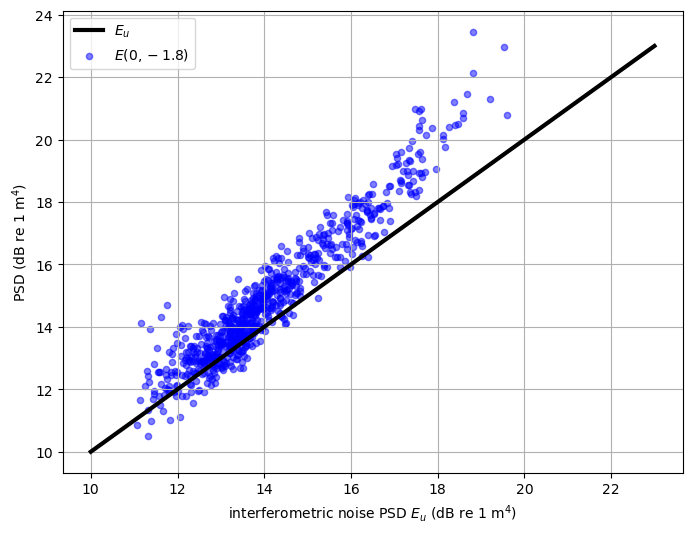

In [11]:
dxdy=(250*235)
W=(ds_seg["uncertainty"].values.flatten().copy()**2)*dxdy*4.376579
Z=np.sqrt(ds_seg["noise_250k"].values.flatten().copy()/dxdy)   
V=ds_seg["sigma0_std"].values.flatten().copy()

inds=np.where(V<0.05)[0]

logZ=10*np.log10(Z[inds]**2*dxdy)  # PSD in dB 
logW=10*np.log10(W[inds])
print(logW[0],logZ[0],ds_seg["noise_250k"][0,0].values)
plt.figure(figsize=(8,6))
sc = plt.plot([10,23],[10,23], c='k', lw=3,label=r'$E_u$')
sc = plt.scatter(logW,logZ, c='b', s=20, alpha=0.5,label=r'$E(0,-1.8)$')
plt.ylabel(r'PSD (dB re 1 m$^4$)')
plt.xlabel(r'interferometric noise PSD $E_{u}$ (dB re 1 m$^4$)')

plt.grid(True)
plt.legend()
plt.savefig("Figure_4d_v2_med_0_18.pdf")


W: (906,)
LEN : 906 768 0.02073456160724163
log val: 13.50010110473474 13.683115112383708
LEN : 768 675
shapes: (768,) (768,)
fit factor: 4.374911676688687 0.9600000000000001


/tmp/ipykernel_122963/2765557003.py:77: RuntimeWarning: invalid value encountered in log10
  YZ=10*np.log10(Y[inds]**2*dxdy-Z[inds]**2*dxdy)  # PSD in dB
/tmp/ipykernel_122963/2765557003.py:78: RuntimeWarning: invalid value encountered in log10
  V=10*np.log10(Z[inds]**2*dxdy-W[inds])  # PSD in dB


Corr Eu,Emin = 0.967  (s=1.376) -4.757221094037263
Corr model Hs = 0.942  (s=1.173) -2.379641575014645
Corr nHQ (X, Z) = 0.636  (s=0.298) 10.215292602432893
Corr(X, Z) = -0.471  (s=-0.171)
10th percentile: 4.05269e-08 nan nan
arctan factor, ratio, log: 30.214491150274633 3.5928074001255697 5.554339365743618
theory factor = 100*dkx*kd/(32*tan theta): 0.0005598804182844363  empirical ; 0.0008333333333333334
theory factor = 100*dkx*kd/(4* tan theta): 0.0015835809616899425  empirical ; 0.0008333333333333334 1785.382581981853 0.0005598800223952009
theory factor = : 0.21986452612139568  empirical ; 0.041666666666666664 ratio= 0.1895106382175581


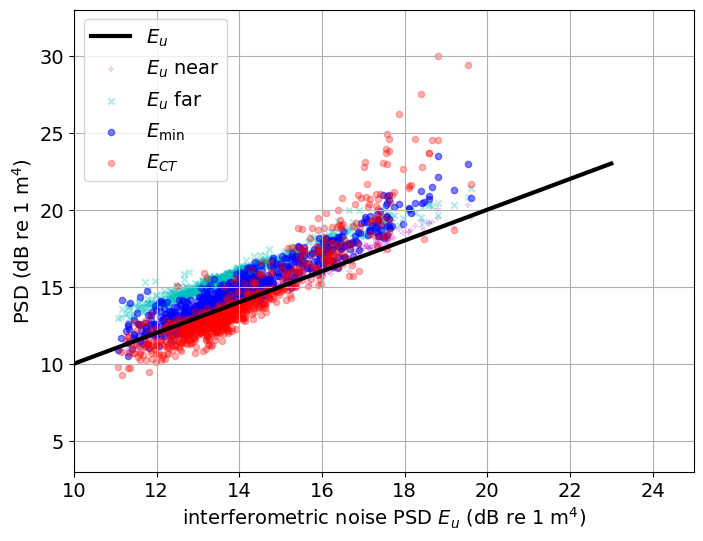

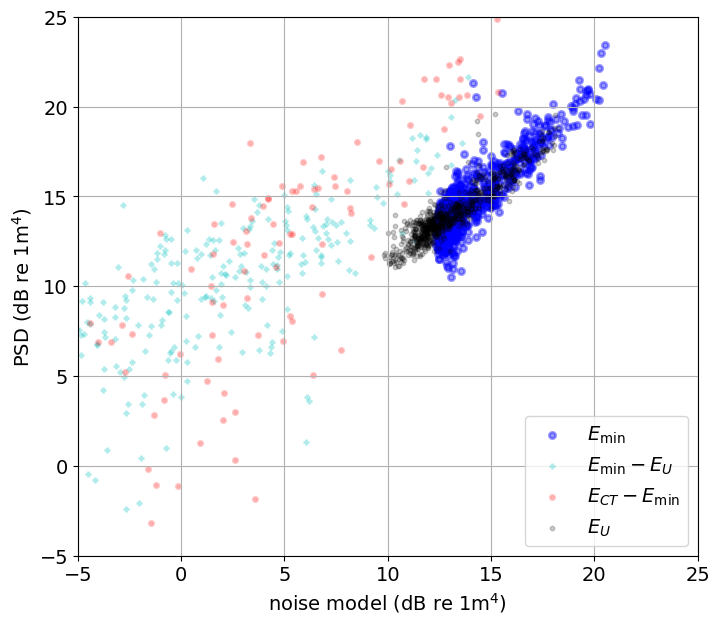

In [12]:
dxdy=(250*235)
DXDY=(4E6)
# mean of PSD of OPB filter is 4.376579 
# mean of PSD of Hamming filter is : 7.1339
#X=df_seg["noiseamp_cm"].values.copy()
V=ds_seg["sigma0_std"].values.flatten().copy()
Y=np.sqrt(ds_seg["noise_250l"].values.flatten().copy()/dxdy)
Z=np.sqrt(ds_seg["noise_250k"].values.flatten().copy()/dxdy)
#W=2.5*ds_seg["uncert"].values.flatten().copy()*DXDY   
W2=7.1339*(ds_seg["uncert"].values.flatten().copy()**2)*DXDY*4.376579   
W=(ds_seg["uncertainty"].values.flatten().copy()**2)*dxdy*4.376579
print('W:',np.shape(W))
logW=10*np.log10(W)

# Correction ... 
#logWc=(logW-18)*1.4+18.2
#W=10**(0.1*logWc)

W3=((ds_seg["uncertainty"].values.flatten().copy()**2+ds_seg["uncertainty_near"].values.flatten().copy()**2+ds_seg["uncertainty_far"].values.flatten().copy()**2)/3)*dxdy*4.376579
W5=(ds_seg["uncertainty_near"].values.flatten().copy()**2)*dxdy*4.376579
W6=(ds_seg["uncertainty_far"].values.flatten().copy()**2)*dxdy*4.376579

#W2=7.1339*(ds_seg["uncert"].values.flatten().copy())*DXDY*4.376579   
#W=(ds_seg["uncertainty"].values.flatten().copy())*dxdy*4.376579
#W3=((ds_seg["uncertainty"].values.flatten().copy()+ds_seg["uncertainty_near"].values.flatten().copy()+ds_seg["uncertainty_far"].values.flatten().copy())/3)*dxdy*4.376579
#W3=(ds_seg["uncertainty_near"].values.flatten().copy())*dxdy*4.376579

inds=np.where(V<0.05)[0]
print('LEN :',len(V),len(inds),np.nanmax(V))

logY=10*np.log10(Y[inds]**2*dxdy)  # PSD in dB 
logZ=10*np.log10(Z[inds]**2*dxdy)  # PSD in dB 

logW=10*np.log10(W[inds])
logW2=10*np.log10(W2[inds])
logW3=10*np.log10(W3[inds])
logW5=10*np.log10(W5[inds])
logW6=10*np.log10(W6[inds])

# taniking into account the 128 dof, assuming n=10 
#YZ=np.log10(np.sqrt(Y**2*0.84-1.14*Z**2))
# taking into account the 128 dof, assuming n=8
#YZ=np.log10(np.sqrt(Y**2*0.88-1.11*Z**2))

####################### 2nd panel
mpl.rcParams.update({'figure.figsize':[9,5.4],'axes.grid' : True,'font.size': 14,'savefig.facecolor':'white'})
plt.figure(figsize=(8,6))
sc = plt.plot([10,23],[10,23], c='k', lw=3,label=r'$E_u$')
sc = plt.scatter(logW,logW5, c='m',marker='+', s=20, alpha=0.2,label=r'$E_{u}$ near')
sc = plt.scatter(logW,logW6, c='c',marker='x', s=20, alpha=0.3,label=r'$E_{u}$ far')

print('log val:',logW[0],logZ[0])
sc = plt.scatter(logW,logZ, c='b', s=20, alpha=0.5,label=r'$E_{\mathrm{min}}$')
sc = plt.scatter(logW,logY, c='r', s=20, alpha=0.3,label=r'$E_{CT}$')
#points =[(17,3,'e'),(123,3,'c'),(180,6,'a'),(170,6,'f'),(110,6,'d'),(181,0,'b')]
#for m, n, label in points:
#    i = m*8 + n
#    x_val = logW[i];y_val = logY[i];z_val = logZ[i]
#    print(label,x_val,y_val,z_val) 
#    # annotate Y (red)
#    plt.annotate(label,xy=(x_val, y_val),xytext=(x_val-1.2, y_val+0.8),arrowprops=dict(arrowstyle="->"))
#    # arrow to Z (blue)
#    plt.annotate("",xy=(x_val, z_val),xytext=(x_val-1, y_val+0.4),arrowprops=dict(arrowstyle="->"))

plt.ylabel(r'PSD (dB re 1 m$^4$)')
plt.xlabel(r'interferometric noise PSD $E_{u}$ (dB re 1 m$^4$)')
plt.xlim([10,25])
plt.ylim([3,33])

plt.grid(True)
plt.legend()
plt.savefig("Figure_4d_v2_med.pdf")




YZ=10*np.log10(Y[inds]**2*dxdy-Z[inds]**2*dxdy)  # PSD in dB 
V=10*np.log10(Z[inds]**2*dxdy-W[inds])  # PSD in dB 
indd=np.where(np.isfinite(V))[0]

print('LEN :',len(V),len(indd))

Vmfactor=-18
Vm=Vmfactor+10*np.log10((qkk_model_seg[inds]*hs_model_seg[inds])**2)

Y=logY
Z=logZ 
W=logW
mask = np.isfinite(Y) & np.isfinite(Z)
Zm=10*np.log10((16*np.exp(0.46*hs_model_seg[inds]))) #   np.log((0.08*1+0.08*hs_model_seg/4.37 ))))/log(10)  =   # log10(a)=log(a)/log(10)
Wm=10*np.log10((20*np.exp(0.23*hs_model_seg[inds]))) #   np.log((0.08*1+0.08*hs_model_seg/4.37 ))))/log(10)  =   # log10(a)=log(a)/log(10)
#Zm=np.log10((0.08+0.018*hs_model_seg[inds])*0.5*(1+0.2*(hs_model_seg[inds]/3)**1.5))
Wm2=9.5+10*np.log10(0.8+ (0.1*wnd_model_seg[inds]+hs_model_seg[inds]**2/5) )
Wm2=10.5+10*np.log10(0.8+ (0.15*wnd_model_seg[inds]+0.15*hs_model_seg[inds]**2) )

print('shapes:',np.shape(Zm),np.shape(Z))
print('fit factor:',(np.log(10)*1.9),(0.0008*1200))
#Ym=np.log10((qkk_model_seg*hs_model_seg)**0.9/110.)

Ym=-28+10*np.log10((qkk_model_seg[inds]*hs_model_seg[inds]**2)**2)

plt.figure(figsize=(8,7))
sc = plt.scatter(Zm,Z, c='b', lw=2, s=20, alpha=0.4,label=r'$E_{\min}$')
sc = plt.scatter(Vm,V, c='c',lw=2,marker='+', s=20, alpha=0.3,label=r'$E_{\min} - E_{U}$')
#sc = plt.scatter(np.sqrt((0.075*np.exp(hs_model_seg/(np.log(10)*1.5)))**2+(qkk_model_seg*hs_model_seg/160.)**2),Y, c='b', s=10, alpha=0.3,label='max')
sc = plt.scatter(Ym,YZ, c='r',lw=2, s=10, alpha=0.2,label=r'$E_{CT}-E_{\min}$')
#sc = plt.scatter(Wm,W, c='m', s=10, alpha=0.2,label=r'$E_{U}$')
sc = plt.scatter(Wm2,W, c='k', s=10, alpha=0.2,label=r'$E_{U}$')
plt.xlabel(r'noise model (dB re 1m$^4$)')
plt.ylabel(r'PSD (dB re 1m$^4$)')
plt.xlim([-5,25])
plt.ylim([-5,25])
plt.legend()
plt.savefig("Figure_5a_med.pdf")

# Drop NaNs to avoid invalid correlations
mask = np.isfinite(Y) & np.isfinite(Z)  & np.isfinite(Ym) & np.isfinite(YZ)

Xc,  Zc = W[mask], Z[mask]
r_XZ, p_XZ = pearsonr(Xc, Zc)
slope_XZ, intercept_XZ, r_XZ, p_XZ, stderr_XZ = linregress(Xc, Zc)
print(f"Corr Eu,Emin = {r_XZ:.3f}  (s={slope_XZ:.3f})",intercept_XZ)


Xc,  Zc = Zm[mask], Z[mask]
r_XZ, p_XZ = pearsonr(Xc, Zc)
slope_XZ, intercept_XZ, r_XZ, p_XZ, stderr_XZ = linregress(Xc, Zc)
print(f"Corr model Hs = {r_XZ:.3f}  (s={slope_XZ:.3f})",intercept_XZ)

# Emin with Hs only: Corr model Hs = 0.906  (s=1.027) -1.0694075964126597 

Xc,  Zc = Ym[mask], YZ[mask]
r_XZ, p_XZ = pearsonr(Xc, Zc)
slope_XZ, intercept_XZ, r_XZ, p_XZ, stderr_XZ = linregress(Xc, Zc)
print(f"Corr nHQ (X, Z) = {r_XZ:.3f}  (s={slope_XZ:.3f})", intercept_XZ)

Xc,  Zc = np.sqrt(Ym[mask]**2+Zm[mask]**2), Y[mask]
r_XZ, p_XZ = pearsonr(Xc, Zc)
slope_XZ, intercept_XZ, r_XZ, p_XZ, stderr_XZ = linregress(Xc, Zc)
print(f"Corr(X, Z) = {r_XZ:.3f}  (s={slope_XZ:.3f})")


dkdk=dkxs.values * dkys.values
NPSD=(0.01*ds_seg["noise_250k"].values.flatten())**2/(dkdk)
print('10th percentile:',dkdk,np.percentile(NPSD, 10),np.sqrt(np.percentile(NPSD, 10)*dkdk))

tant=35/857
arctant=857*np.mean(1/np.arange(15,55,1))
arctanf=857*np.mean(1/np.arange(35,55,1))
arctann=857*np.mean(1/np.arange(15,35,1))
ratio=(arctann/arctanf)**2
print('arctan factor, ratio, log:',857/arctant,ratio,np.log10(ratio)*10)
print('theory factor = 100*dkx*kd/(32*tan theta):',((2*np.pi)**2)*100*2E-4*8E-4*arctant/32,' empirical ;',1/1200)
print('theory factor = 100*dkx*kd/(4* tan theta):',((2*np.pi)**2)*100*2E-4*8E-4*arctant*np.sqrt(8)/32,' empirical ;',1/1200,1200*0.000833/0.00055988,1/(1200*0.0008333333/0.00055988))
print('theory factor = :',((2*np.pi)**3)*1E-3*arctant/32,' empirical ;',1/(1200*100*2E-4),'ratio=',1/(1200*100*2E-4)/(((2*np.pi)**3)*1E-3*arctant/32))





In [13]:
mpl.rcParams.update({'figure.figsize':[10,6],'axes.grid' : True,'font.size': 10,'savefig.facecolor':'white'})
Xn=100*uncert_seg_var.copy()

def plot_spectrum(i, s):
    fig = plt.figure(figsize=(20, 6))
    gs = gridspec.GridSpec(
    2, 4,
    height_ratios=[20, 1],   # small row for colorbars
    width_ratios=[1, 1, 1, 1],
    hspace=0.35,
    wspace=0.12)

    axs = [
    fig.add_subplot(gs[0, 0]),
    fig.add_subplot(gs[0, 1]),
    fig.add_subplot(gs[0, 2]),
    fig.add_subplot(gs[0, 3])
    ]

    cax0 = fig.add_subplot(gs[1, 0])
    cax1 = fig.add_subplot(gs[1, 1])
    cax2 = fig.add_subplot(gs[1, 2])
    # gs[1,2] intentionally unused

    fs1 = 20

    X=ds_seg["noise_250k"][:, s].values
    Y=ds_seg["noise_250l"][:, s].values
    Z=np.sqrt(Y**2-X**2)
    W=((ds_seg["uncertainty"][:, s].values)**2)*dxdy*4.376579
    V=ds_seg["sigma0_std"][:, s].values

    logX=10*np.log10(X)  # PSD in dB 
    logY=10*np.log10(Y)  # PSD in dB 
    logW=10*np.log10(W)

    
    # ==========================================================
    # 1️⃣ --- LOAD SSH FILE (per strip) ---
    # ==========================================================
    ssh_file = ds_seg["ssh_filenames"][i].item()
    print('I,S:',i,s,ssh_file)
    if ssh_file is None:
        print("SSH file not found.")
        return

    if  ds_seg["side"][i].values == 0:
        ddl = xr.open_dataset(ssh_file, group='left') 
        side=0
    else: 
        ddl = xr.open_dataset(ssh_file, group='right') 
        side=1
 

    ssha = ddl.ssh_karin_2 #ssha_unedited
    lat = ddl.latitude.values
    sig0 = ddl.sig0_karin_2   #sigma0
    unce = ddl.ssh_karin_uncert   #sigma0
    #flas = ddl.quality_flag

    # ==========================================================
    # 2️⃣ --- GET BOX INDICES (from ds_seg) ---
    # ==========================================================
    j1 = int(j1_indices[i, s]) #-41
    j2 = int(j2_indices[i, s]) #+41
    i1 = int(i1_indices[i, s]) #-40
    i2 = int(i2_indices[i, s]) #+40
    if (i1 > 300): 
        i2=i2-(359-79) 
        i1=i1-(359-79) 
        
    # ==========================================================
    # 3️⃣ --- BUILD SSH PANEL ---
    # ==========================================================
    dx, dy, indxc, ISHIFT, *_ = swell.spec_settings_for_L3(1, 'alpha')

    latmean=0.5*(lat[j2, 80 ]+ lat[j1, 80 ])
   
    X = (np.arange(ssha.shape[1]) - indxc*(1-side)) * dx / 1000
    Y = (np.arange(ssha.shape[0]) - j1) * dy / 1000

    #mybox, *_ = swell.SWOTarray_flip_north_up(
    #    ssha[j1:j2, i1:i2],
    #    flas[j1:j2, i1:i2],
    #    sig0[j1:j2, i1:i2],
    #    X, Y
    #)
    mybox=ssha[j1:j2, i1:i2].values.copy()
    #detrenda = mybox - np.nanmean(mybox)
    print('shape :',i1,i2,j1,j2,np.shape(mybox))
    detrenda = detrend_2d_bilinear(mybox)
    print('all nan?',np.isnan(detrenda[j1:j2, i1:i2]).all())
    print('shape :',np.shape(detrenda))
    amax = np.nanmax(np.abs(detrenda))

    #im0 = axs[0].pcolormesh(X[i1:i2], Y[j1:j2], detrenda, cmap=lightcmap,vmin=-amax, vmax=amax,rasterized=True )
    #fig.colorbar(im0, cax=cax0,orientation='horizontal',label='surface elevation (m)')

    #im0 = axs[0].pcolormesh(X[i1:i2], Y[j1:j2], 10*np.log10(unce[j1:j2, i1:i2]**2),rasterized=True )
    im0 = axs[0].pcolormesh(X[i1:i2], Y[j1:j2], unce[j1:j2, i1:i2],rasterized=True )
    unce_rms=np.sqrt(np.nanmean(unce[j1:j2, i1:i2]**2))
    print('uncert.:',unce_rms,np.sqrt(W[i]/(dxdy*4.376579)),logW[i] )
    rms=np.nanstd(detrenda)
    print('std:',rms,logX[i])
    fig.colorbar(im0, cax=cax0,orientation='horizontal',label='uncertainty (cm)')
    
    #plt.colorbar(im0, ax=axs[0],
    #             label='surface elevation (m)',
    #             location='bottom', shrink=0.8)

    axs[0].set_xlabel('cross-track (km)', fontsize=fs1)
    axs[0].set_ylabel('along-track (km)', fontsize=fs1)
    axs[0].set_title('rms:'+f"{unce_rms*100:.2f}"+' cm, lat: '+f"{latmean:.2f}"+'°')


    kx2s = ds_seg["fx2D"].values
    ky2s = ds_seg["fy2D"].values
    # Maximum energy marker
    fy_max = int(ds_seg.max_indices_fy[i, s].values)
    fx_max = int(ds_seg.max_indices_fx[i, s].values)
    # Minimum energy marker
    fy_min = int(ds_seg.min_indices_fy[i, s].values)
    fx_min = int(ds_seg.min_indices_fx[i, s].values)
    # ==========================================================
    # 4️⃣ --- SPECTRUM PANEL ---
    # ==========================================================
    im1 = axs[1].pcolormesh(X[i1:i2], Y[j1:j2], detrenda,rasterized=True )

    #E=ds_seg["Efxfy_f"][i, s].values/ds_seg["Efxfy_n"][i, s].values
    #im1 = axs[1].pcolormesh(kx2s * 1000,ky2s * 1000,10 * np.log10(E),norm=mcolors.Normalize(vmin=-5, vmax=5),rasterized=True, cmap='seismic')
    #axs[1].scatter(kx2s[fy_min, fx_min] * 1000,ky2s[fy_min, fx_min] * 1000,color='blue', s=50,edgecolor='white')
    #axs[1].scatter(kx2s[fy_max, fx_max] * 1000,ky2s[fy_max, fx_max] * 1000,color='red', s=50,edgecolor='white')

    axs[1].set_title('std:'+f"{rms*100:.2f}"+' cm')
    #plt.colorbar(im1, ax=axs[1],
    #             label='dB re 1 m$^4$',
    #             location='bottom', shrink=0.8)

    fig.colorbar(im1, cax=cax1,
             orientation='horizontal',
             label='ssha (cm)')
#             label='ratio far/near (dB)')
#    axs[1].set_xlabel('$k_x$ (cycles / km)', fontsize=fs1)
    axs[1].set_xlabel('cross-track (km)', fontsize=fs1)

    # ==========================================================
    # 4️⃣ --- SPECTRUM PANEL ---
    # ==========================================================
    E = ds_seg["Efxfy"][i, s].values
    medi=np.nanmedian(10 * np.log10(E))
    vmin=medi-5
    vmax=medi+5
    im1 = axs[2].pcolormesh(kx2s * 1000,ky2s * 1000,10 * np.log10(E),norm=mcolors.Normalize(vmin=vmin, vmax=vmax),rasterized=True, cmap='seismic')

    fig.colorbar(im1, cax=cax2,
             orientation='horizontal',
             label='dB re 1 m$^4$')

    axs[2].set_xlabel('$k_x$ (cycles / km)', fontsize=fs1)

    axs[2].scatter(kx2s[fy_min, fx_min] * 1000,ky2s[fy_min, fx_min] * 1000,color='blue', s=50,edgecolor='white')
    axs[2].scatter(kx2s[fy_max, fx_max] * 1000,ky2s[fy_max, fx_max] * 1000,color='red', s=50,edgecolor='white')
    
    parts = ssh_file.split('_')
    axs[2].set_title(parts[-5]+'_'+parts[-4]+'_'+parts[-3])


        
    #sc = axs[2].scatter(df_seg["noiseamp_cm"], 3*ds_seg["noise_250k"], c='r', s=10, alpha=0.3,label='min of 2D spectrum from 250 m grid')

    axs[3].scatter( logW, logY, c='r', s=10, alpha=0.5,label='E(red dot)')
    axs[3].scatter( logW[i],logY[i], c='k', s=80, alpha=0.4)  #label='min of 2D spectrum from 250 m grid')
    axs[3].scatter( logW, logX, c='b', s=10, alpha=0.5,label='E(blue dot)')
    axs[3].scatter( logW[i],logX[i], c='k', s=80, alpha=0.4)  #label='min of 2D spectrum from 250 m grid')

    axs[3].set_xlabel(r'E_{u} (dB re 1 m4)')
    axs[3].set_ylabel('PSD (dB re 1 m4)')
    axs[3].yaxis.tick_right()                 # ticks on the right
    axs[3].yaxis.set_label_position("right")  # ylabel on the right    #plt.title('SSH noise at different scales (for 40-km long segments)')
    #plt.legend()
    axs[3].grid(True)
    axs[3].legend()


    
    plt.show()
    fig.savefig("noise_level_med_"+f"{i:03d}"+'_'+f"{s:03d}"+".png",dpi=100)    
    #fig.savefig("noise_level_med_"+f"{i:03d}"+f"{s:03d}"+".pdf")

In [15]:
def detrend_2d_bilinear(data):
    rows, cols = data.shape
    x, y = np.meshgrid(np.arange(cols), np.arange(rows))
    x = x.flatten()
    y = y.flatten()
    Z = data.flatten()

    # Design matrix
    X = np.column_stack([np.ones_like(x), x, y, x*y])

    # Solve for coefficients
    beta, _, _, _ = np.linalg.lstsq(X, Z, rcond=None)

    # Reconstruct the trend
    trend = X @ beta
    trend = trend.reshape(rows, cols)

    # Detrend
    detrended = data - trend
    return detrended


interact(
    plot_spectrum,
    i=IntSlider(min=0, max=len(good_strips_list)-1, step=1, value=118, description="cycle/side index"),
    s=IntSlider(min=0, max=num_seg-1, step=1, value=0, description="segment"),
)

# points = [(17,3,'e'),(123,3,'c'),(180,6,'a'),(170,6,'f'),(110,6,'c'),(181,0,'d')]

interactive(children=(IntSlider(value=118, description='cycle/side index', max=150), IntSlider(value=0, descri…

<function __main__.plot_spectrum(i, s)>